In [86]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands

train_info = GraphsTraining()

In [88]:
pyomo_3_df = Results.flatten_convergence_data(load_all_pickles("results/study_vdp_3_no_pretrain/pyomo_vdp_64_280226"), key_list=["system", "pretrain", "max_t"], model_type="pyomo")

Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/1052116968_2026-02-28_05-13.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/1052670860_2026-02-28_04-25.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/1133138628_2026-02-28_11-53.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/2072979834_2026-02-28_10-04.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/2613490689_2026-02-28_03-04.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/289039256_2026-02-28_10-57.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/3178557402_2026-02-28_09-22.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/3360447420_2026-02-28_06-42.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/347064316_2026-02-28_08-32.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/3887444887_2026-02-28_01-28.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/389676590_2026-02-28_02-29.pkl
Loaded results/study_vdp_3_1/pyomo_vdp_64_280226/4061638174_2026-02-28_03-40.pkl
Loaded results/study_vdp_3_1/py

In [90]:
results_li_16 = load_all_pickles("results/study_vdp/pyomo_vdp_16", recursive=False)
results_df_16 = Results.flatten_convergence_data(results_li_16, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

results_li_32 = load_all_pickles("results/study_vdp/pyomo_vdp_32__29_Nov", recursive=False)
results_df_32 = Results.flatten_convergence_data(results_li_32, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

results_li_48 = load_all_pickles("results/study_vdp/pyomo_vdp_48__8_Dec", recursive=False)
results_df_48 = Results.flatten_convergence_data(results_li_48, key_list=["system", "pretrain", "max_t"], model_type="pyomo").drop(columns = ["mse_train", "mse_test"]).rename(columns={"mse_train_coll": "mse_train", "mse_test_coll": "mse_test"})

results_li_64 = load_all_pickles("results/study_vdp/pyomo_vdp_64__8_Dec", recursive=False)
results_df_64 = Results.flatten_convergence_data(results_li_64, key_list=["system", "pretrain", "max_t"], model_type="pyomo").drop(columns = ["mse_train", "mse_test"]).rename(columns={"mse_train_coll": "mse_train", "mse_test_coll": "mse_test"})

Loaded results/study_vdp/pyomo_vdp_16/1521817625_2025-11-09_11-15.pkl
Loaded results/study_vdp/pyomo_vdp_16/194654574_2025-11-09_10-09.pkl
Loaded results/study_vdp/pyomo_vdp_16/2044567532_2025-11-09_09-16.pkl
Loaded results/study_vdp/pyomo_vdp_16/2156445085_2025-11-09_07-59.pkl
Loaded results/study_vdp/pyomo_vdp_16/2166546916_2025-11-09_07-35.pkl
Loaded results/study_vdp/pyomo_vdp_16/2198121026_2025-11-09_12-02.pkl
Loaded results/study_vdp/pyomo_vdp_16/2264735367_2025-11-09_10-30.pkl
Loaded results/study_vdp/pyomo_vdp_16/2379440660_2025-11-09_11-38.pkl
Loaded results/study_vdp/pyomo_vdp_16/239331939_2025-11-09_06-52.pkl
Loaded results/study_vdp/pyomo_vdp_16/2431345690_2025-11-09_06-32.pkl
Loaded results/study_vdp/pyomo_vdp_16/246802394_2025-11-09_07-12.pkl
Loaded results/study_vdp/pyomo_vdp_16/2537183847_2025-11-09_08-51.pkl
Loaded results/study_vdp/pyomo_vdp_16/2677561965_2025-11-09_10-52.pkl
Loaded results/study_vdp/pyomo_vdp_16/2799231986_2025-11-09_13-19.pkl
Loaded results/study_vd

In [91]:
pyomo_comparison_dfs = {
    "pyomo_16": results_df_16,
    "pyomo_32": results_df_32,
    "pyomo_48": results_df_48,
    "pyomo_64": results_df_64[(results_df_64["time_elapsed"].notna())],
    "pyomo_3" : pyomo_3_df,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


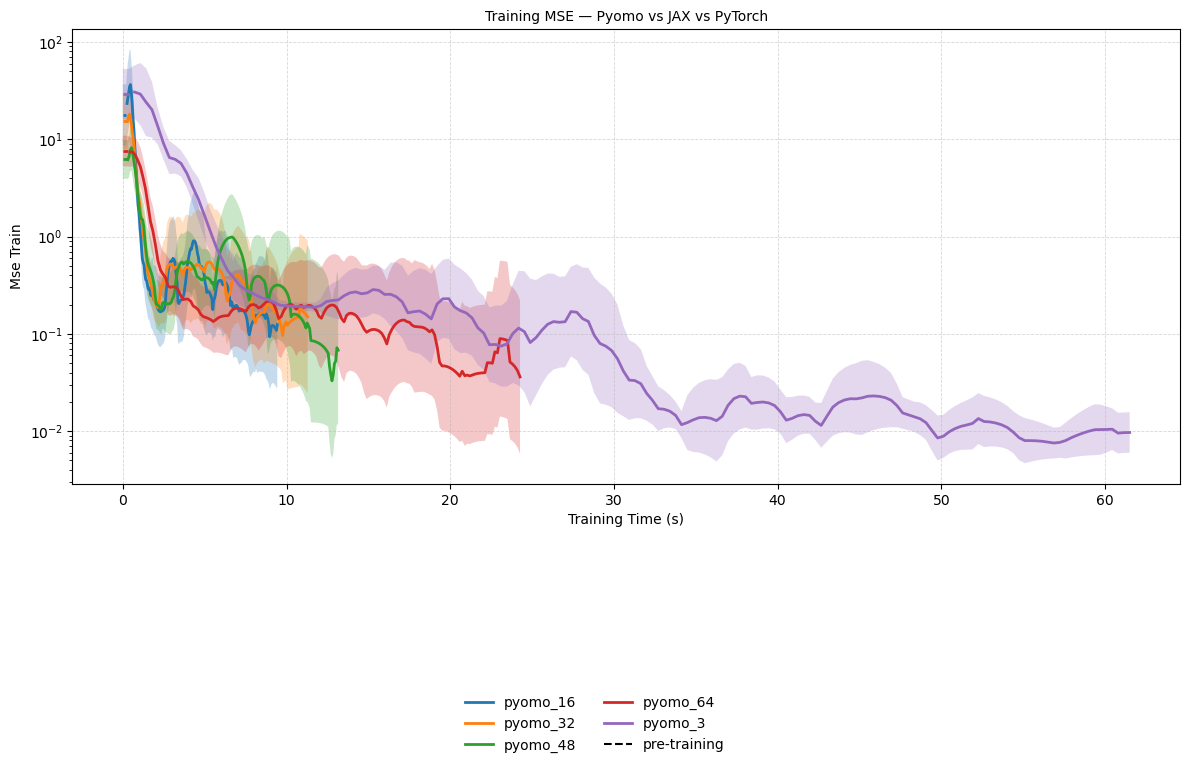

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train'>

In [94]:
plot_time_bands(
    pyomo_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

In [186]:

results = load_all_pickles("results/study_vdp/pytorch_vdp_400_1000_w32", recursive=False)
pytoch_results_df_400_w32 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/pytorch_vdp_200_1000_w32", recursive=False)
pytoch_results_df_200_w32 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/pytorch_vdp_1000_w32", recursive=False)
pytoch_results_df_no_pretrain_32 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/pytorch_vdp_400_1000_w64", recursive=False)
pytoch_results_df_400_w64 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/pytorch_vdp_1000_w64", recursive=False)
pytoch_results_df_no_pretrain_64 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp_3/pytorch_vdp_400_1000_260226", recursive=False)
pytoch_results_df_3 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp_3_no_pretrain/pytorch_vdp_w3-64-2_1000_280226", recursive=False)
pytoch_results_df_3_no_pretrain = Results.flatten_convergence_data(results, model_type="pytorch")

Loaded results/study_vdp/pytorch_vdp_400_1000_w32/1695354516_2025-11-05_05-25.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/2160758465_2025-11-05_07-17.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/2281306231_2025-11-05_07-01.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/238721462_2025-11-05_04-54.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/2611119799_2025-11-05_06-29.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/2775691197_2025-11-05_05-34.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/2903296063_2025-11-05_06-05.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/3038528068_2025-11-05_06-45.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/3136801043_2025-11-05_06-37.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/3217644072_2025-11-05_07-09.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/3285674571_2025-11-05_06-21.pkl
Loaded results/study_vdp/pytorch_vdp_400_1000_w32/3583963625_2025-11-05_07-25.pkl
Loaded results/st

In [189]:
pytorch_comparison_dfs = {
    "pytoch_results_df_3" : pytoch_results_df_3,
    "pytoch_results_df_3_no_pretrain": pytoch_results_df_3_no_pretrain,
    # "pytoch_results_df_no_pretrain_64" : pytoch_results_df_no_pretrain_64,
    "pytoch_results_df_400_w64": pytoch_results_df_400_w64
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


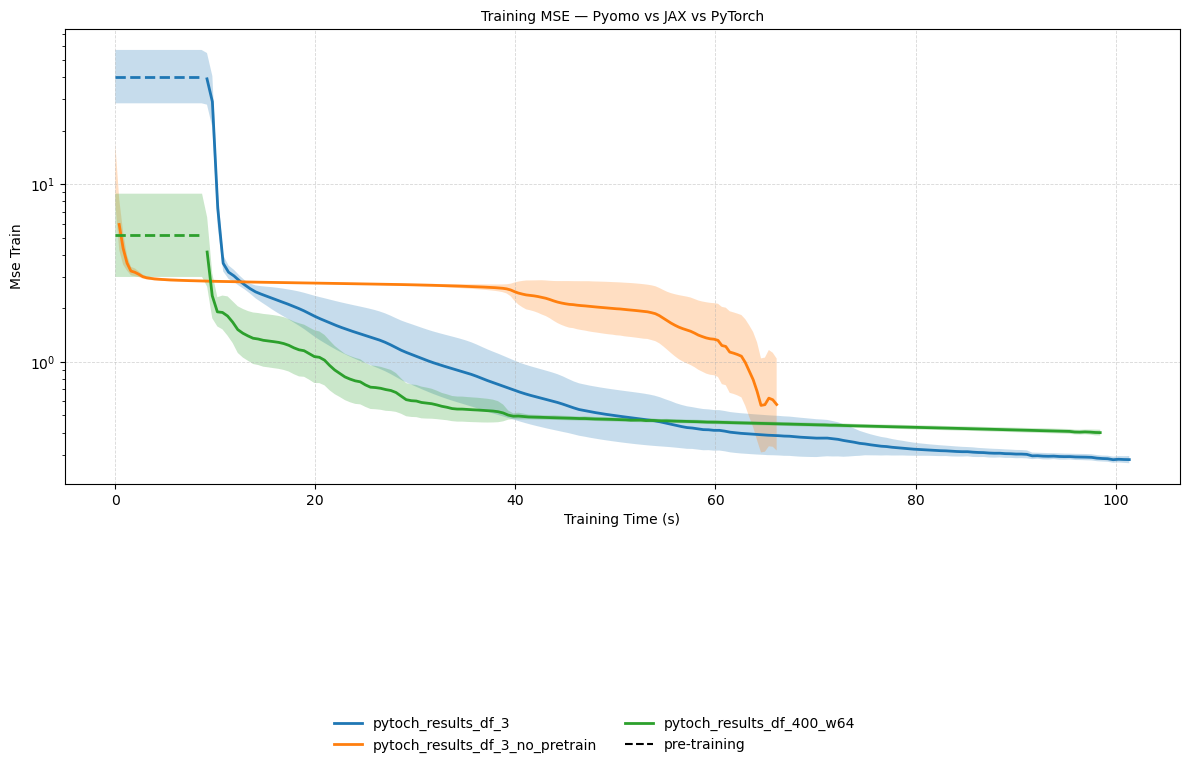

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train'>

In [190]:
plot_time_bands(
    pytorch_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

### jax

In [191]:
results = load_all_pickles("results/study_vdp/jax_vdp_500_10000_w32", recursive=False)
jax_vdp_500_10000_w32 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_500_10000_w64", recursive=False)
jax_vdp_500_10000_w64 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_1000_10000_w32", recursive=False)
jax_vdp_1000_10000_w32 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_1000_10000_w64", recursive=False)
jax_vdp_1000_10000_w64 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_15000_w32", recursive=False)
jax_vdp_15000_w32 = Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_15000_w64", recursive=False)
jax_vdp_15000_w64= Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_1000_40000_w_reg_norm", recursive=False)
jax_vdp_10000_40000_w64= Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp/jax_vdp_50000_w_reg_norm", recursive=False)
jax_vdp_50000_w64= Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp_3/jax_vdp_w3-64-2_1000_25000_250226_2158", recursive=False)
jax_vdp_3_w64= Results.flatten_convergence_data(results, model_type="pytorch")

results = load_all_pickles("results/study_vdp_3_no_pretrain/jax_vdp_w3-64-2_50000_280226_1607", recursive=False)
jax_vdp_3_w64_no_pre = Results.flatten_convergence_data(results, model_type="pytorch")

Loaded results/study_vdp/jax_vdp_500_10000_w32/1369350520_2025-12-09_03-58.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/1623065689_2025-12-09_07-15.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/1976251261_2025-12-09_03-47.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/2110002138_2025-12-09_06-56.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/2288038114_2025-12-09_03-26.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/271543652_2025-12-09_06-27.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/2805819702_2025-12-09_04-08.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/300208958_2025-12-09_04-01.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/3055703713_2025-12-09_07-07.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/3212447012_2025-12-09_03-40.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/3401736888_2025-12-09_06-49.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/3773686843_2025-12-09_06-45.pkl
Loaded results/study_vdp/jax_vdp_500_10000_w32/3895046

In [192]:
jax_comparison_dfs = {
    "jax_vdp_500_10000_w32": jax_vdp_500_10000_w32,
    "jax_vdp_500_10000_w64": jax_vdp_500_10000_w64,
    "jax_vdp_1000_10000_w32": jax_vdp_1000_10000_w32,
    "jax_vdp_1000_10000_w64": jax_vdp_1000_10000_w64,
    "jax_vdp_15000_w32": jax_vdp_15000_w32,
    "jax_vdp_15000_w64": jax_vdp_15000_w64,
    "jax_vdp_1000_40000": jax_vdp_10000_40000_w64,
    "jax_vdp_50000": jax_vdp_50000_w64,
    #"jax_vdp_pyomo_pretrain": jax_vdp_pyomo_pretrain,
}

jax_comparison_B_dfs = {
    "jax_vdp_1000_40000_w64": jax_vdp_10000_40000_w64,
    #"jax_vdp_pyomo_pretrain": jax_vdp_pyomo_pretrain,
    "jax_no_pretraining": jax_vdp_50000_w64,
    "jax_3": jax_vdp_3_w64,
    "jax_vdp_3_w64_no_pre": jax_vdp_3_w64_no_pre,
    "pytoch_results_df_3_no_pretrain": pytoch_results_df_3_no_pretrain
}


/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


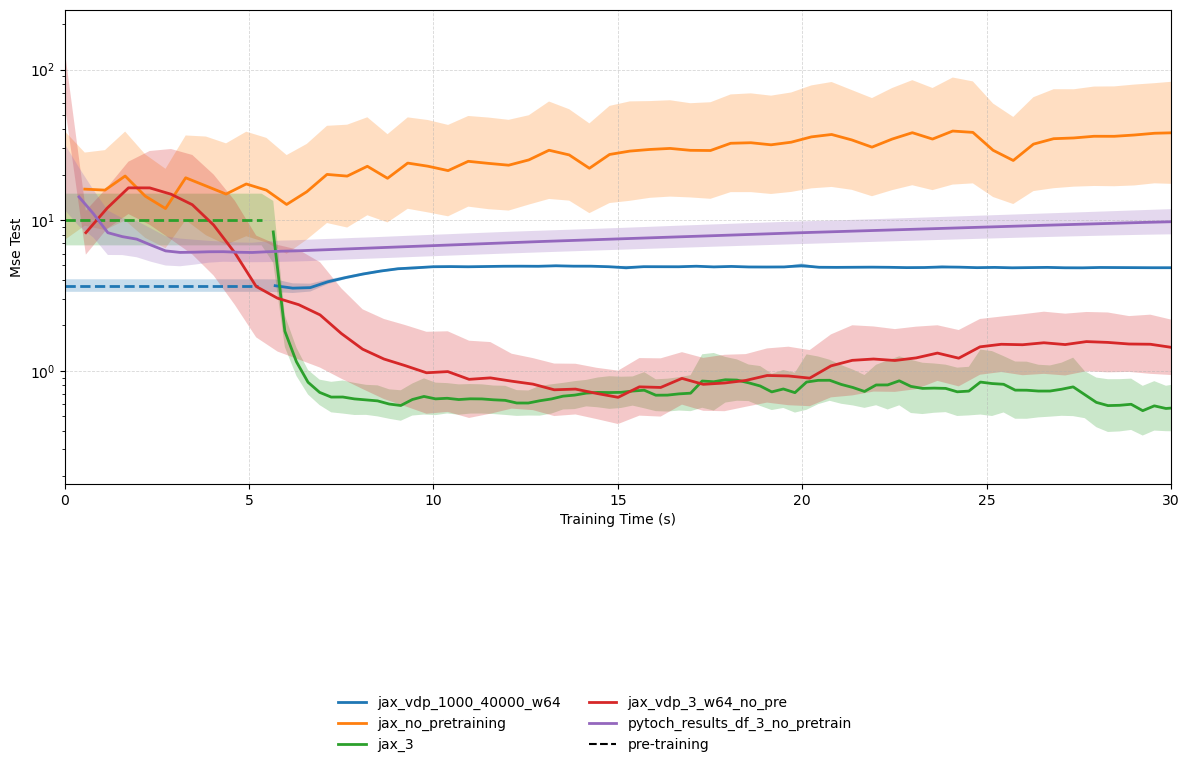

<Axes: xlabel='Training Time (s)', ylabel='Mse Test'>

In [193]:
plot_time_bands(
    jax_comparison_B_dfs,
    y_col="mse_test",  # or "mse_test"
    logy=True,
    align_grid = False,
    min_support_abs=1,
    xlim =(0, 30)
)

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


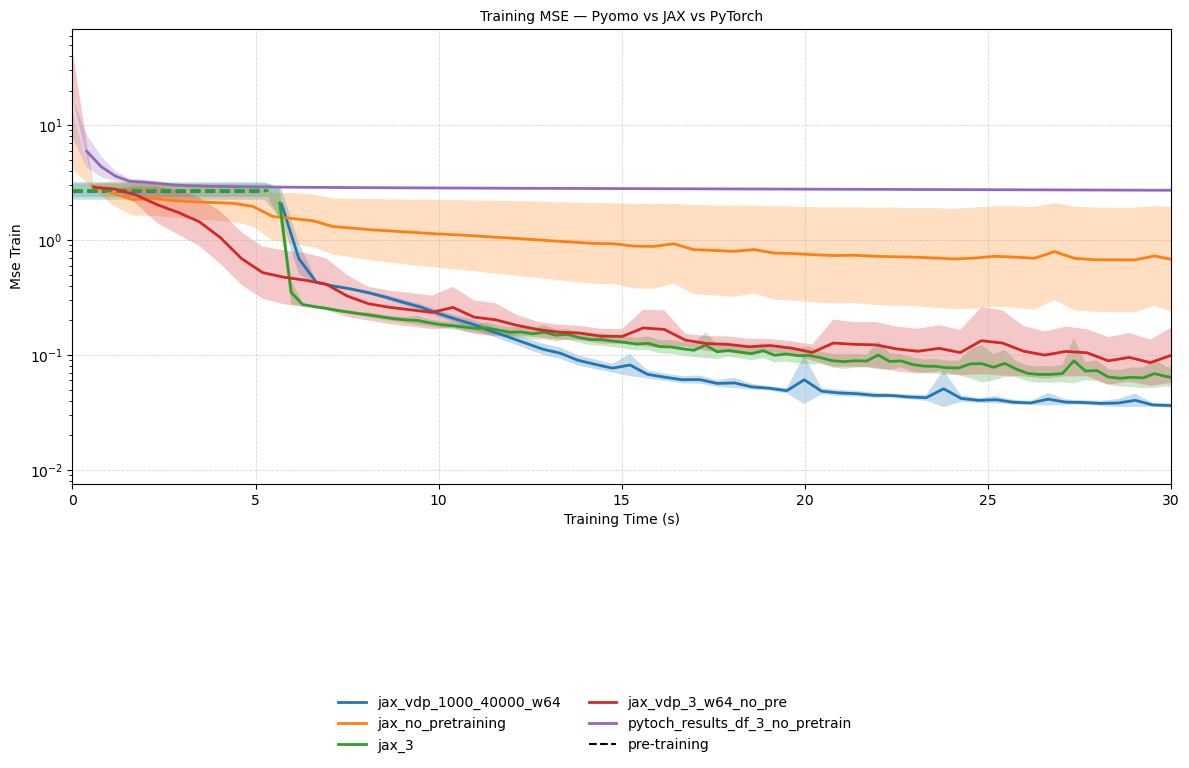

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train'>

In [194]:
plot_time_bands(
    jax_comparison_B_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False,
    min_support_abs=1,
    xlim =(0, 30)
)

In [195]:
results = load_all_pickles("results/jax_pretrain_pyomo_vdp_w2-64-2/jax_vdp_5000_311225", recursive=False)


Loaded 0 files from results/jax_pretrain_pyomo_vdp_w2-64-2/jax_vdp_5000_311225


In [210]:

results_df_64["pretrain"] = False

comparison_dfs_no_pretrain = {
    # "pyomo_w32": results_df_32,
    "Pyomo": results_df_64,
    "JAX": jax_vdp_50000_w64,
    "JAX_3": jax_vdp_3_w64_no_pre,
    "PyTorch": pytoch_results_df_no_pretrain_64,
}

comparison_dfs = {
    # "pyomo_w32": results_df_32,
    "Pyomo": pyomo_3_df, #results_df_64,
    # "JAX": jax_vdp_3_w64, #jax_vdp_10000_40000_w64,
    "PyTorch": pytoch_results_df_3, #pytoch_results_df_400_w64,
    "JAX_3": jax_vdp_3_w64_no_pre,
    "pytoch_results_df_3_no_pretrain": pytoch_results_df_3_no_pretrain
}

In [211]:
max_q_maps = {
    "Pyomo": 1.0,
    "JAX": 0.85,
    "PyTorch": 0.6,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


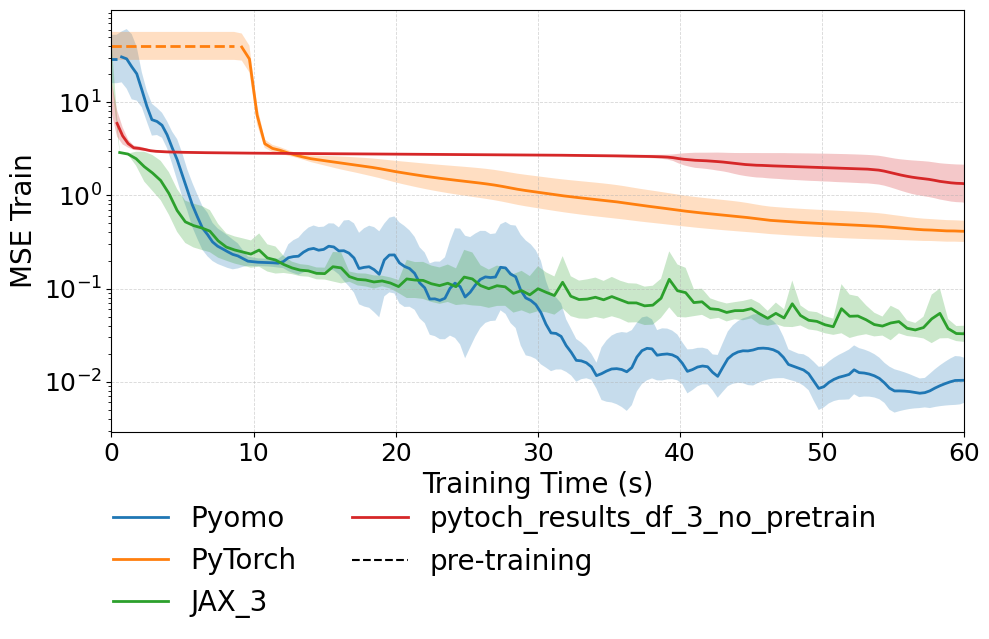

<Axes: xlabel='Training Time (s)', ylabel='MSE Train'>

In [212]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=16,
    # tmax_quantile=max_q_maps,
    xlim =(0, 60),
    y_label="MSE Train",
    legend_bbox_y=-0.08,
    legend_ncol=2,
)

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


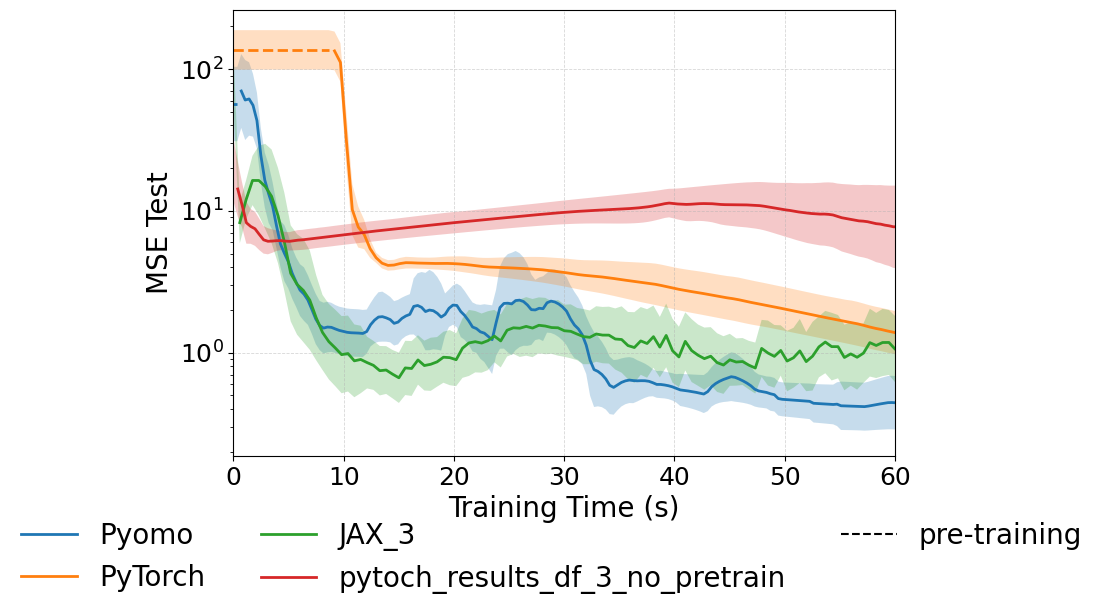

<Axes: xlabel='Training Time (s)', ylabel='MSE Test'>

In [213]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=16,
    xlim =(0, 60),
    y_label="MSE Test",
    legend_bbox_y=-0.04,
    legend_ncol=3,
)